# ASR Test Simulation: Explore and Run Modflow 6 Simulation with no Chemistry

NOTE: This [Jupytext](https://jupytext.readthedocs.io/en/latest/index.html) paired notebook, with paired `.py` and `.ipynb` files. 
- If using VS Code, install the the [Jupytext Sync extension](https://jupytext.readthedocs.io/en/latest/vs-code.html) for maximum benefit.


The workflow for this example:
- Read geochemical components and their initial and boundary concentrations from PHREEQC input files
- Create new Modflow 6 transport model for each aqueous phase (components in the Solution blocks) and add their initial concentrations over the entire DISV grid.
- Modify the Modflow 6 Flow Well package Stress Period Data (SPD) by adding Solution component concentrations.
- Run the modified Modflow 6 for conservative transport of all components (i.e. no coupling to PHREEQC)
- Run the coupled Modflow 6 & PHREEQC models for the entire simulation



## Simple ASR Test Case

Grid type: DISV  
Grid Size: ~4800 ft x 4700 ft  
Grid cells 1.2 ft – 155 ft  
Cells per layer = 1032  
Total cells = 5160  

Grid Layers:
 - Layer 1: heads of all cells specified with CHD
 - Layer 2: side boundaries set with GHB
 - Layer 3: side boundaries set with GHB
 - Layer 4: side boundaries set with GHB
 - Layer 5: heads of all cells specified with CHD

ASR Well simulated using WEL package
 - 21 Stress Periods

New stress period when ASR pumping changes and at the start of each month
 - ~ 10-day time steps
 - Simulation run time ~25-30 seconds

Simplifying assumptions:
 - ASR Well injected or extracted at a constant rate of 5 MGD
 - TDS and temperature of injected water was constant at 150 mg/L and 25C
 - GHBs were setup using map coverages in GMS.  Heads were pulled from the old KRASR SEAWAT local scale model at a few points along the test model boundary, then the map module was used to interpolate the heads to the boundary cells.  The head contours along the boundaries look a little strange during injection and recovery, but it should be ok for the purposes of the test model
 - TDS and temperature were assumed to be constant along the model boundaries but varied by model layer based on the KRASR local scale model results
 - Specific storage was constant for each layer

# Installation and Setup

Create a custom conda virtual environment can be created using the `environment.yml` file included in this repo.

## Python Imports

In [1]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

import flopy
from modflowapi import ModflowApi

In [2]:
# Import the MFRTM package, installed using `conda develop`
import mf6rtm

display(mf6rtm.__file__)
try:
    # if current LimnoTech development version
    display(mf6rtm.__version__)
except AttributeError:
    pass

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


'/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm/mf6rtm/__init__.py'

'0.3.1+develop'

In [3]:
import utils # from this repo

### If you get `ModuleNotFoundError`

Run the `01-GettingStarted.ipynb` notebook to install `mf6rtm` using `conda develop`.

## Set Paths to Input and Output Files with `pathlib`

Use the [pathlib](https://docs.python.org/3/library/pathlib.html) library 
(built-in to Python 3) to manage paths indpendentely of OS or environment. 
See this [blog post]
(https://medium.com/@ageitgey/python-3-quick-tip-the-easy-way-to-deal-with-file-paths-on-windows-mac-and-linux-11a072b58d5f) 
to learn about the many benefits over using the `os` library.

In [4]:
# Find your current working directory, which should be folder for this notebook.
working_dir = Path.cwd()
# Find repository path (i.e. the parent to `/examples` directory for this notebook)
repo_path = working_dir.parent.parent
repo_path

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example')

In [5]:
simulation_name = working_dir.name
simulation_name

'sim01-mf6only'

In [6]:
# Path to simulation workspace, which is git-ignored and 
# will get over-written with each run of this notebook
sim_ws = working_dir / 'ws'
sim_ws.mkdir(parents=True, exist_ok=True)

### Reset Workspace

In [7]:
# Delete previous contents from simulation
if sim_ws.exists():
    try:
        shutil.rmtree(sim_ws)
        print(f"Directory '{sim_ws}' and its contents removed successfully.")
        sim_ws.mkdir(parents=True, exist_ok=True)
    except OSError as e:
        print(f"Error: {sim_ws} : {e.strerror}")
else:
    print(f"Directory '{sim_ws}' does not exist.")

Directory '/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim01-mf6only/ws' and its contents removed successfully.


### Modflow Inputs

In [8]:
# Modflow inputs file folder
mf6_inputs_path = repo_path / 'data' / 'MF6_ASR_DISV_inputs2'
                                    # sim 2 = 10ft resolution near well (vs 2ft for original)

In [9]:
# Copy input files to simulation workspace directory)
shutil.copytree(mf6_inputs_path, sim_ws, dirs_exist_ok=True)

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim01-mf6only/ws')

In [10]:
# Add required empty output folders
folders = [
    'flow_output',
    'trans-TDS_output',
    'trans-temp_output',
]
for folder in folders:
    path = sim_ws / folder
    path.mkdir(parents=True, exist_ok=True)

In [11]:
# Set filepath for the MF6 simulation configuration file
sim_nam_file_path = sim_ws / "mfsim.nam"
assert sim_nam_file_path.exists()
sim_nam_file_path

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim01-mf6only/ws/mfsim.nam')

In [12]:
# Set modflow input path equal to simulation workspace
mf6_input_path = sim_ws

## Set Path to MF6 Executable & Library
Different versions can be downloaded from: https://github.com/MODFLOW-ORG/executables to a folder similar to this: `bin/mf6.5.0/macarm` 

On Mac, will need to give permissions with these terminal commands from the 
```sh
xattr -dr com.apple.quarantine mf6
xattr -dr com.apple.quarantine libmf6.dylib
```


In [13]:
use_version_installed_with_modflowapi = False
# user = "Laren"
user = "Anthony"
os = "macarm"

# version = "6.4.2"
version = "6.5.0"
# version = "6.7.0.dev3"

try:
    mf6_exe = Path(flopy.which("mf6"))
    dll = mf6_exe.parent.parent / "lib" / "libmf6.dylib" # MacOS only for now
    mf6_version = !{mf6_exe} --version
    mf6dll_version = ModflowApi(dll).get_version()
    print(f"Executable & library installed with modflowapi: {mf6_version[1]}, dll: {mf6dll_version}")
except Exception:
    print("Modflow executables not found in environment")

if use_version_installed_with_modflowapi:
    print(f"Using executable installed with modflowapi: {mf6_version[1]}")
else:
    if user == "Lauren":
        # If using executable from GMS
        mf6_bin_path = Path(r"C:/program files/gms 10.8 64-bit/python/lib/site-packages/xms/executables/modflow6")
        mf6_exe = mf6_bin_path / "mf6.exe"
        dll = mf6_bin_path / "libmf6.dll"
    elif user == "Anthony":
        mf6_potential_paths = [
            repo_path / "bin" / f"mf{version}" / os,
            repo_path / "bin" / f"mf{version}_{os}" / "bin",
        ]
        for path in mf6_potential_paths:
            if path.exists():
                mf6_bin_path = path
        mf6_exe = mf6_bin_path / "mf6"
        dll = mf6_bin_path / "libmf6.dylib"
    else:
        print("Create a new user and set paths to mf6 and libmf6")
    mf6_version = !{mf6_exe} --version
    mf6dll_version = ModflowApi(dll).get_version()
    print(f"User-selected executable ({mf6_exe.exists()}): {mf6_version[1]}, dll: {mf6dll_version}")

Executable & library installed with modflowapi: mf6: 6.6.3 09/29/2025, dll: 6.6.3
User-selected executable (True): mf6: 6.5.0 05/23/2024, dll: 6.5.0


In [14]:
# Copy executable and library to simulation workspace
shutil.copy2(mf6_exe, sim_ws)
shutil.copy2(dll, sim_ws)
(sim_ws/mf6_exe.name).exists()

True

# Load Modflow 6 Simulation for Reactive Transport
To set up PhreeqcRM and MF6RTM simulation objects.
Modifies Modflow 6 input files to include transport models for all reactive transport species.

In [15]:
# Load simulation using Flopy
sim = flopy.mf6.MFSimulation.load(
    sim_ws=sim_ws,
    exe_name=mf6_exe,  #'mf6',
    verbosity_level=0,
)
sim.model_names

['flow', 'trans-tds', 'trans-temp']

## Read Flow Model

In [16]:
# load existing gwf model
for model_name in sim.model_names:
    model = sim.get_model(model_name)
    if model.model_type == "gwf6":
        gwf = model
        print(gwf.name)
gwf.get_package_list()

flow


['DISV', 'NPF', 'IC', 'OC', 'STO', 'BUY', 'WEL', 'CHD', 'GHB']

In [17]:
# modify npf package to save specific discharge
npf = gwf.get_package("npf")
npf.save_specific_discharge = True

In [18]:
# write updated simulation input files
sim.write_simulation()

## Read Grid Info

In [19]:
# Get groundwater model names and grid info
for model_name in sim.model_names:
    # Collect model info 
    model = sim.get_model(model_name)
    model_type = model.model_type
    grid_type = model.get_grid_type()
    grid_units = model.modelgrid.units
    # Collect grid information
    grid_package = model.get_package(grid_type.name)
    nlay = grid_package.nlay.get_data()  # number of layers
    ncpl = grid_package.ncpl.get_data()  # number of cells per layer
    print(f"{model_name}: ", model_type, grid_type.name, grid_units, nlay, ncpl)

flow:  gwf6 DISV feet 5 957
trans-tds:  gwt6 DISV feet 5 957
trans-temp:  gwt6 DISV feet 5 957


In [20]:
# Use spatial discretization info from the last model
# Calculate total number of grid cells
nxyz = nlay * ncpl
nxyz

4785

### Cell Spacing

In [21]:
grid_package.length_units

{internal}
('feet')

In [22]:
celldata = grid_package.cell2d.get_data()
# data stored in numpy record arrays  
# can be easily converted to pandas dataframes
cells_df = pd.DataFrame.from_records(celldata, index='icell2d')
cells_df

,xc,yc,ncvert,icvert_0,icvert_1,icvert_2,icvert_3,icvert_4,icvert_5
icell2d,,,,,,,,,
0,694376.127565,1.027689e+06,4,3,2,1,0,None,None
1,694530.764694,1.027689e+06,4,5,4,2,3,None,None
2,694685.401823,1.027689e+06,4,7,6,4,5,None,None
3,694840.038952,1.027689e+06,4,9,8,6,7,None,None
4,694994.676081,1.027689e+06,4,11,10,8,9,None,None
...,...,...,...,...,...,...,...,...,...
952,698396.692919,1.023169e+06,4,993,1025,1024,992,None,None
953,698551.330048,1.023169e+06,4,994,1026,1025,993,None,None
954,698705.967177,1.023169e+06,4,995,1027,1026,994,None,None


In [23]:
verticedata = grid_package.vertices.get_data()
vertices_df = pd.DataFrame.from_records(verticedata, index='iv')
vertices_df

,xv,yv
iv,,
0,694298.809000,1.027767e+06
1,694298.809000,1.027611e+06
2,694453.446129,1.027611e+06
3,694453.446129,1.027767e+06
4,694608.083258,1.027611e+06
...,...,...
1025,698474.011484,1.023091e+06
1026,698628.648613,1.023091e+06
1027,698783.285742,1.023091e+06


In [24]:
domain_size = vertices_df.max() - vertices_df.min()
domain_size

xv    4793.751
yv    4675.366
dtype: float64

### Cell Volumes

In [25]:
### Calculate grid cell volume
cell2D = grid_package.cell2d.get_data()
cell2D_df = pd.DataFrame.from_records(cell2D, index='icell2d')
vertices = grid_package.vertices.get_data()
vertices_df = pd.DataFrame.from_records(vertices, index='iv')
top = grid_package.top.array
botm = grid_package.botm.array

### Calculate surface area of each grid cell within a single layer
for cell in range(len(cell2D_df)):
    ### get vertice coordinates to calc surface area
    temp_cell_info = cell2D_df.iloc[[cell]]
    # read each vert_1 - 5
    icverts = temp_cell_info.filter(like="icvert_").iloc[0].to_list()
    # remove Nones
    icverts_clean = [int(v) for v in icverts if v is not None]
    # look up (x,y) and create x and y arrays
    x_l = vertices_df.loc[icverts_clean,"xv"].to_numpy()
    y_l = vertices_df.loc[icverts_clean,"yv"].to_numpy()
    # calculate surface area based on min/max x/y from array
    surface_area = (np.max(x_l)-np.min(x_l)) * (np.max(y_l) - np.min(y_l))
    cell2D_df.loc[cell,'surface_area'] = surface_area

### Calc layer thickness for each layer
# initialize thickness array
thickness = np.zeros_like(botm)
# for layer 1:
thickness[0] = top - botm[0]
# for layers 2:nlay
thickness[1:] = botm[:-1] - botm[1:]

### Calculate volume for each grid cell
# initialize volume array
cell_volumes = np.zeros((nlay,ncpl))
# calculate volume for entire grid
for k in range(nlay):
    cell_volumes[k,:] = cell2D_df['surface_area'].to_numpy() * thickness[k,:]

In [26]:
pd.DataFrame(cell_volumes).T.describe()

,0,1,2,3,4
count,9.570000e+02,9.570000e+02,9.570000e+02,9.570000e+02,9.570000e+02
mean,3.761185e+06,9.765966e+06,5.480182e+06,5.175728e+06,1.002358e+07
std,5.917141e+05,1.536393e+06,8.621488e+05,8.142516e+05,1.576922e+06
min,6.047470e+04,1.570233e+05,8.811382e+04,8.321861e+04,1.611654e+05
25%,3.870381e+06,1.004949e+07,5.639284e+06,5.325991e+06,1.031459e+07
50%,3.870381e+06,1.004949e+07,5.639284e+06,5.325991e+06,1.031459e+07
75%,3.870381e+06,1.004949e+07,5.639284e+06,5.325991e+06,1.031459e+07
max,3.870381e+06,1.004949e+07,5.639284e+06,5.325991e+06,1.031459e+07


In [27]:
cell_volumes[2,:].min()

np.float64(88113.81825380816)

In [28]:
np.where(cell_volumes == cell_volumes[2,:].min())

(array([2, 2]), array([461, 463]))

In [29]:
# volume of cells near well screen
cell_volumes[2, 456:468]

array([ 352455.27301523,  352455.27301523,  352455.27301524,
        352455.27301418,   88113.81825434,   88113.81825381,
         88113.81825434,   88113.81825381,  352455.27301523,
       1409821.09205884, 1409821.09205884, 1409821.09206095])

### Grid Cell Map

In [30]:
# Turn on interactive
%matplotlib widget

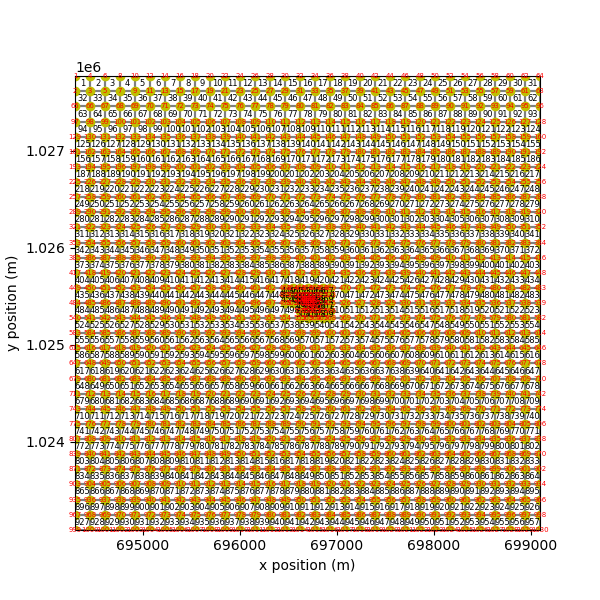

In [31]:
# plot map view of grid showing order of grid cell ids and vertices from:
# https://modflow6-examples.readthedocs.io/en/latest/_notebooks/ex-gwf-u1disv.html
fig = plt.figure(figsize=(6,6))
fig.tight_layout()
ax = fig.add_subplot(1, 1, 1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
pmv.plot_grid()
pmv.plot_bc(name="ghb", alpha=0.75)
pmv.plot_bc(name="wel", alpha=0.75)
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
for i, (x, y) in enumerate(
    zip(gwf.modelgrid.xcellcenters, gwf.modelgrid.ycellcenters)
):
    ax.text(
        x,
        y,
        f"{i + 1}",
        fontsize=6,
        horizontalalignment="center",
        verticalalignment="center",
    )
v = gwf.disv.vertices.array
ax.plot(v["xv"], v["yv"], "yo")
for i in range(v.shape[0]):
    x, y = v["xv"][i], v["yv"][i]
    ax.text(
        x,
        y,
        f"{i + 1}",
        fontsize=5,
        color="red",
        horizontalalignment="center",
        verticalalignment="center",
    )
plt.show()

#### Screenshot of Grid Cell Map
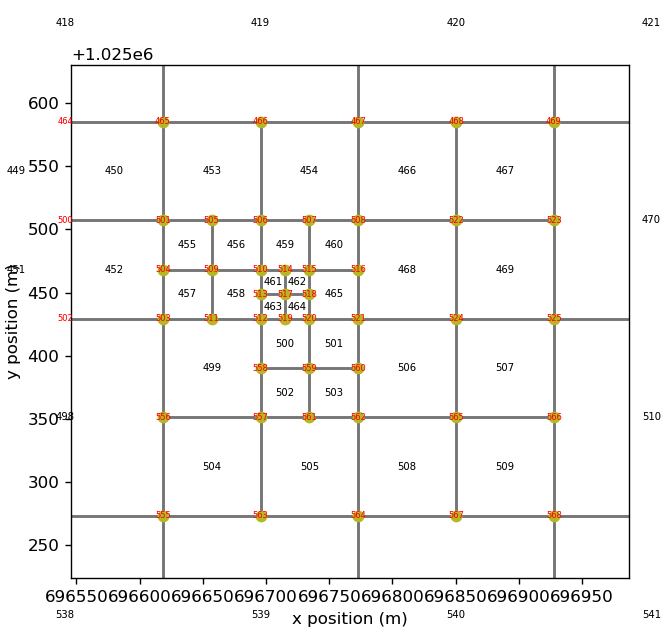

In [32]:
# Turn off interactive widget
%matplotlib inline

## Read Time Info

### Time Steps

In [33]:
# Get time discretization info from the `tdis` package
tdis = sim.tdis
nper = tdis.nper.get_data()          # number of stress periods
perioddata = tdis.perioddata.get_data() # record array
nstp = perioddata['nstp']            # number of timesteps per stress period
perlen = perioddata['perlen']        # length of stress periods
tsmult = perioddata['tsmult']        # timestep multiplier
t_units = tdis.time_units.get_data() # units

print(f'{nper} stress periods. Units: {t_units}')
perioddata

21 stress periods. Units: days


rec.array([( 1., 1, 1.), (13., 2, 1.), (28., 3, 1.), (31., 3, 1.),
           (30., 3, 1.), (31., 3, 1.), (30., 3, 1.), ( 9., 1, 1.),
           (22., 2, 1.), (31., 3, 1.), (30., 3, 1.), (31., 3, 1.),
           (30., 3, 1.), (31., 3, 1.), ( 3., 1, 1.), (28., 3, 1.),
           (28., 3, 1.), (31., 3, 1.), (30., 3, 1.), (31., 3, 1.),
           (16., 2, 1.)],
          dtype=[('perlen', '<f8'), ('nstp', '<i8'), ('tsmult', '<f8')])

In [34]:
pd.DataFrame.from_records(perioddata)

,perlen,nstp,tsmult
0,1.0,1,1.0
1,13.0,2,1.0
2,28.0,3,1.0
3,31.0,3,1.0
4,30.0,3,1.0
5,31.0,3,1.0
6,30.0,3,1.0
7,9.0,1,1.0
8,22.0,2,1.0
9,31.0,3,1.0


### Stress Period Data

In [35]:
# boundary conditions for chem_stress
# get boundary condition packages with transport
# read in spd stress period data ... which varries based on package...

# for well package (wel):
wel = gwf.get_package('wel')
if wel.has_stress_period_data == True:
    spd_wel_dict = wel.stress_period_data.get_data(full_data=True) # full data is default
display(spd_wel_dict)

# modify well q to try and address convergence issues
change_well_q = False
if change_well_q == True:
    for sp in range(1,len(spd_wel_dict)):
        if sp > 0:
            spd_wel_dict[sp]['q'] = spd_wel_dict[sp]['q'] / 2.
            #spd_wel_dict[sp]['q'] = abs(spd_wel_dict[sp]['q'] / 2.)
        #else:
        #    spd_wel_dict[sp]['q'] = 0.

    # reset wel stress period data using modified q
    wel.stress_period_data = spd_wel_dict
    spd_wel_dict_edit = wel.stress_period_data.get_data(full_data=True)

{0: rec.array([((2, 462), 0, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<i8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 1: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 2: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 3: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 4: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 5: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0.,

In [36]:
# data stored in a dictionary of numpy record arrays, 
# each of which can be easily converted to a pandas dataframe
stress_period_id = 3
pd.DataFrame.from_records(spd_wel_dict[stress_period_id])

,cellid,q,tds,temp,cellgrp,boundname
0,"(2, 462)",668359.8449,0.00429,25,0.0,krasr


In [37]:
# flopy has a convenient dataframe interface 
# that also includes, the auxilary data (i.e. components) when present
spd_wel_df_dict = wel.stress_period_data.dataframe
spd_wel_df_dict[stress_period_id]

,cellid_layer,cellid_cell,q,tds,temp,cellgrp,boundname
0,2,462,668359.8449,0.00429,25,0.0,krasr


In [38]:
# ... which allows easy concatination into a single dataframe
spd_wel_df = pd.concat(spd_wel_df_dict.values(), keys=spd_wel_df_dict.keys())
spd_wel_df = spd_wel_df.droplevel(level=1)
# spd_wel_df.index.set_names(['stress_period_id'], inplace=True)
spd_wel_df.info()
spd_wel_df

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cellid_layer  21 non-null     int64  
 1   cellid_cell   21 non-null     int64  
 2   q             21 non-null     float64
 3   tds           21 non-null     float64
 4   temp          21 non-null     int64  
 5   cellgrp       21 non-null     float64
 6   boundname     21 non-null     object 
dtypes: float64(3), int64(3), object(1)
memory usage: 1.3+ KB


,cellid_layer,cellid_cell,q,tds,temp,cellgrp,boundname
0,2,462,0.000000,0.00429,25,0.0,krasr
1,2,462,668359.844900,0.00429,25,0.0,krasr
2,2,462,668359.844900,0.00429,25,0.0,krasr
3,2,462,668359.844900,0.00429,25,0.0,krasr
4,2,462,668359.844900,0.00429,25,0.0,krasr
5,2,462,668359.844900,0.00429,25,0.0,krasr
6,2,462,668359.844900,0.00429,25,0.0,krasr
7,2,462,668359.415142,0.00429,25,0.0,krasr
8,2,462,0.000000,0.00429,25,0.0,krasr
9,2,462,0.000000,0.00429,25,0.0,krasr


NOTE: `cellid` is the cell identifier, and depends on the type of grid that is used for the simulation. 
- For a structured grid that uses the DIS input file, CELLID is the layer, row, and column. 
- For a grid that uses the DISV input file, CELLID is the layer and CELL2D number. 
- If the model uses the unstructured discretization (DISU) input file, CELLID is the node number for the cell.

## Get Tranport Models & Components
Which are all conservative for this MF6-only simulation.

In [39]:
gwt_model_names = [name for name in sim.model_names 
                    if (sim.get_model(name).model_type == 'gwt6')]
print("Number of transport models: ",len(gwt_model_names))
gwt_model_names

Number of transport models:  2


['trans-tds', 'trans-temp']

In [40]:
component_name_l = [name.replace('trans-',"") 
                    for name in gwt_model_names]
component_name_l

['tds', 'temp']

# Run Modflow 6 simulation only

To confirm that conservative transport is occuring as expected.

In [41]:
utils.run_models(sim, silent=False)

FloPy is using the following executable to run the model: ../../../bin/mf6.5.0/macarm/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

        MODFLOW 6 compiled Jun 21 2024 02:51:39 with GCC version 12.3.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held liable for any damages resulting from its 
authorized or unauthorized use. Also refer to the USGS Water 
Resour

## Plot MF6 Transport Results with no Reactions

When just running MF6, before any coupling

In [42]:
# Get transport components
for model_name in sim.model_names:
    # Collect model info 
    model = sim.get_model(model_name)
    model_type = model.model_type

In [43]:
# lookup cell ID of wel package cell
wel_spd = gwf.wel.stress_period_data.array
wel_cellid = wel_spd[0]["cellid"][0]
wel_cellid
wel_lay = wel_cellid[0]
wel_cellnum = wel_cellid[1]

In [44]:
# read in results for plots

# head in well cell over time
head = gwf.output.head().get_alldata()
times_h = gwf.output.head().get_times()

# concentration of each component in well cell overtime
conc = utils.get_concentrations(sim, component_name_l)
times_c = utils.get_times_c(sim, component_name_l)

# get specific discharge
bud_flow = gwf.output.budget()
spdis = bud_flow.get_data(text="DATA-SPDIS")

ValueError: datafile error: file is empty: /Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim01-mf6only/ws/trans-TDS.ucn

In [ ]:
# Conc is a nested array of these shapes
display(conc.shape, conc[0].shape)

### Head

In [ ]:
# plot head
f = 101
fig = plt.figure(num=f, figsize=(18, 5))
plt.plot(times_h, head[:, wel_lay, 0, wel_cellnum], marker=".")
f = f + 1
fig.show()

### Conc Timeseries near Well 

In [ ]:
# Create list of components to plot based on intersection with transported components
components_to_plot = [c for c in component_name_l if c in ['Ca', 'Cl', 'K', 'N', 'Na']]
components_to_plot

In [ ]:
k = wel_lay  # layer index
cnum = wel_cellnum  # cell number
for c in range(len(component_name_l)):
    if component_name_l[c] in components_to_plot:
        fig = plt.figure(num=101, figsize=(10, 5))
        plt.plot(times_c[c], conc[c][:, k, 0, cnum], label=component_name_l[c])
        plt.title("[" + str(k) + "," + str(cnum) + "]")
        plt.legend()

In [ ]:
# Get Concentration Values
c = -1
time = 5
layer = 2
cell_num = wel_cellnum + 20
print(component_name_l[c], cell_num)
conc[c][0:time, layer, 0, cell_num]

### temp and tds gwt output

In [ ]:
# temp and tds gwt output

temp_tds_l = ["temp", "tds"]
temp_tds_output = utils.get_concentrations(sim, temp_tds_l)
times_temptds = utils.get_times_c(sim, temp_tds_l)
for c in range(len(temp_tds_l)):
    fig = plt.figure(figsize=(18, 5))
    plt.plot(times_temptds[c], temp_tds_output[c][:, k, 0, cnum])
    plt.title(temp_tds_l[c] + " [" + str(k) + "," + str(cnum) + "]")
# tds and temp plan view figures
s = 1  # temp_tds_l index
t_l = [0, 5, 10, 30, 50, -1]  # list of timestep index (NOT actual time/days)
for t in t_l:
    fig = plt.figure(figsize=(24, 4))
    ax = fig.add_subplot(1, 1, 1, aspect="auto")
    ax.set_title("conc of " + temp_tds_l[s] + " at timestep index t=" + str(t))
    mapview = flopy.plot.PlotMapView(gwf, layer=3)  # ,extent=(0,0.08,0,1.))
    patch_collection = mapview.plot_array(
        temp_tds_output[s][t, :, :, :]
    )  # ,vmin=26.600, vmax=26.61)
    linecollection = mapview.plot_grid()
    cb = plt.colorbar(patch_collection, shrink=0.75)

### Conc Cross Sections

In [ ]:
# xsection
# to plot a cross section with disv, you have to make a line to plot along

line = np.array([(694298, 1025429), (6999092, 1025429)])
# creates a plot showing where the line is on the grid to make the cross section plot
fig = plt.figure(figsize=(24, 4))
ax = fig.add_subplot(1, 1, 1, aspect="auto")
ax.set_title("Vertex Model Grid (DISV) with cross sectional line")
# ax.set_xlim(0,0.08)
# ax.set_ylim(0,1.)
# use PlotMapView to plot a DISV (vertex) model
mapview = flopy.plot.PlotMapView(gwf, layer=1)  # ,extent=(0,0.08,0,1.))
# mapview.plot_bc("WEL-1")
# mapview.plot_bc("CHD-1")
linecollection = mapview.plot_grid()
# plot the line over the model grid
lc = plt.plot(line.T[0], line.T[1], "r--", lw=0.8)
plt.show()

In [ ]:
# creates a cross section along the line specified above for each timestep in t_l
s = 0  # solute index for TDS
t_l = [1, 10, 25, 50, -1]  # list of timestep index (NOT actual time/days)
normalize = True
if normalize == True:
    scale = 50
else:
    scale = 100
for t in t_l:
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
        spdis[t], gwf, head=head[t]
    )
    fig = plt.figure(figsize=(9, 2.5))
    ax = fig.add_subplot(1, 1, 1)
    if normalize == True:
        ax.set_title(
            "normalized specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    else:
        ax.set_title(
            "specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    xsect = flopy.plot.PlotCrossSection(model=gwf, line={"line": line})
    patch_collection = xsect.plot_array(conc[s][t, :, :, :], vmin=0.0, vmax=1.0)
    line_collection = xsect.plot_grid()
    quiver = xsect.plot_vector(
        qx,
        qy,
        qz,
        head=head,
        hstep=2,
        normalize=normalize,
        color="white",
        scale=scale,  # changes arrow length
        width=0.003,
        headwidth=3,
        headlength=3,
        headaxislength=3,
        zorder=10,
    )
    cb = plt.colorbar(patch_collection, shrink=0.75)
    ## TODO: add a legend for the quiver to relate to spdis magnitude when noralized = False..?

### Conc Map View

In [ ]:
s = 0  # solute index for TDS
t_l = [0, 1, 10, 50, -1]  # list of timestep index (NOT actual time/days)
for t in t_l:
    fig = plt.figure(figsize=(24, 4))
    ax = fig.add_subplot(1, 1, 1, aspect="auto")
    ax.set_title("conc of " + component_name_l[s] + " at timestep index t=" + str(t))
    mapview = flopy.plot.PlotMapView(gwf, layer=2)  # ,extent=(0,0.08,0,1.))
    patch_collection = mapview.plot_array(conc[s][t, :, :, :])  # ,vmin=0., vmax=0.2)
    linecollection = mapview.plot_grid()
    cb = plt.colorbar(patch_collection, shrink=0.75)

## Calculate Cr number (Courant Condition)

In [ ]:
porosity = 0.3

In [ ]:
################################################################################
##### calculate Cr number (Courant Condition)

### get grid cell dimensions

cell2D = grid_package.cell2d.get_data()
cell2D_df = pd.DataFrame.from_records(cell2D, index='icell2d')
vertices = grid_package.vertices.get_data()
vertices_df = pd.DataFrame.from_records(vertices, index='iv')
top = grid_package.top.array
botm = grid_package.botm.array

### calculate surface area of each grid cell within a single layer
for cell in range(len(cell2D_df)):
    ### get vertice coordinates to calculate dx and dy
    temp_cell_info = cell2D_df.iloc[[cell]]
    # read each vert_1 - 5
    icverts = temp_cell_info.filter(like="icvert_").iloc[0].to_list()
    # remove Nones
    icverts_clean = [int(v) for v in icverts if v is not None]
    # look up (x,y) and create x and y arrays
    x_l = vertices_df.loc[icverts_clean,"xv"].to_numpy()
    y_l = vertices_df.loc[icverts_clean,"yv"].to_numpy()
    # calculate dx and dy 
    dx_temp = (np.max(x_l)-np.min(x_l))
    dy_temp = (np.max(y_l)-np.min(y_l))
    surface_area = (np.max(x_l)-np.min(x_l)) * (np.max(y_l) - np.min(y_l))
    cell2D_df.loc[cell,'dx'] = dx_temp
    cell2D_df.loc[cell,'dy'] = dy_temp

# convert dx and dy to numpy array
dx = cell2D_df['dx'].to_numpy()
dy = cell2D_df['dy'].to_numpy()

# calc layer dz for each layer
# initialize dz array
dz = np.zeros_like(botm)
# for layer 1:
dz[0] = top - botm[0]
# for layers 2:nlay
dz[1:] = botm[:-1] - botm[1:]

### read in specific discharge (flow through a cross section)
bud_flow = gwf.output.budget()
spdis = bud_flow.get_data(text="DATA-SPDIS")
head = gwf.output.head().get_alldata()

qx_l = []
qy_l = []
qz_l = []

for t in range(len(head)):
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
        spdis[0], gwf, head=head[0]
    )
    qx_l.append(qx)
    qy_l.append(qy)
    qz_l.append(qz)

"""qx, qy, qz are ndarrays of size (nlay, nrow, ncol) for a structured grid or 
size (nlay, ncpl) for an unstructured grid. The sign of qy is such that the y 
axis is considered to increase in the north direction. The sign of qz is such 
that the z axis is considered to increase in the upward direction. Note: if a 
head array is provided, inactive and dry cells are set to NaN."""

### calculate pore water velocity (q/n) (flow through the pores)
v_pw_x = np.array(qx_l)/porosity
v_pw_y = np.array(qy_l)/porosity
v_pw_z = np.array(qz_l)/porosity

### calculate Cr number (v_pore_water * dt / cell_dimention)
Cr = np.full_like(v_pw_x, np.nan)
dt = float(perlen[0]/nstp[0]) ## TODO: implement for variable dt

for t in range(Cr.shape[0]):
    Cr_x_temp = abs(v_pw_x[t]) * dt / dx
    Cr_y_temp = abs(v_pw_y[t]) * dt / dy
    Cr_z_temp = abs(v_pw_z[t]) * dt / dz
    Cr[t] = np.round(np.maximum(np.maximum(Cr_x_temp,Cr_y_temp),Cr_z_temp),decimals=5)

print('Cr > 1:  ' + str(np.where(Cr>1.)))
print('Cr > 0.5:  ' + str(np.where(Cr>0.5)))

# plot Cr map view
t_l = [0, 1, 2, 5, 8, -1]  # list of timestep index (NOT actual time/days)
for t in t_l:
    fig = plt.figure(num=f,figsize=(6, 4))
    ax = fig.add_subplot(1, 1, 1, aspect="auto")
    ax.set_title("Cr at timestep index t=" + str(t))
    mapview = flopy.plot.PlotMapView(gwf, layer=2)  # ,extent=(0,0.08,0,1.))
    patch_collection = mapview.plot_array(Cr[t,:,:])  # ,vmin=0., vmax=0.2)
    linecollection = mapview.plot_grid()
    cb = plt.colorbar(patch_collection, shrink=0.75)
    f = f + 1

# END